# U-Net Downscaling — With vs. Without Semivariogram Regularizer

This is the core experiment. Train the **same** U-Net twice on the simulated
data:

1. **Baseline:** MSE loss only.
2. **Regularized:** MSE + λ · semivariogram penalty.

Then compare how well each reproduces the *known* spatial structure of the
targets. Because the data was generated from a known Matérn model
(`sim_dataset.npz`), we have ground truth to judge against.

**Pipeline**
- Load the paired `(coarse_stacks → fine_targets)` data.
- Define a differentiable semivariogram penalty (torch ops, so gradients flow).
- Define a small U-Net that upsamples the coarse stack to the fine grid.
- Train baseline and regularized versions with identical settings.
- Compare MSE, R², and predicted-vs-true semivariograms.

## Setup

In [1]:
import sys
!{sys.executable} -m pip install torch numpy matplotlib gstools


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3.10 install --upgrade pip


In [2]:
# !pip install torch numpy matplotlib gstools
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.13.0 | device: cpu


## Load the simulated data

`coarse_stacks` are the inputs (N, T, h, w); `fine_targets` are the targets
(N, H, W). We also keep the generating parameters — they're the ground-truth
structure we'll evaluate against.

In [3]:
data = np.load("sim_dataset.npz")
coarse_stacks = data["coarse_stacks"]     # (N, T, h, w)
fine_targets  = data["fine_targets"]      # (N, H, W)
TRUE = dict(var=float(data["var"]), len_scale=float(data["len_scale"]),
            nu=float(data["nu"]), coarse_factor=int(data["coarse_factor"]))

N, T, h, w = coarse_stacks.shape
_, H, W = fine_targets.shape
print("coarse_stacks:", coarse_stacks.shape)
print("fine_targets :", fine_targets.shape)
print("true structure:", TRUE)
print(f"upsampling factor: {H // h}x")

# NOTE: this uploaded dataset has only N=16 samples (quick-config). That is
# far too few for meaningful training — results here are a plumbing test.
# Regenerate with the full SimConfig (n_samples=200) for real experiments.

coarse_stacks: (200, 3, 80, 80)
fine_targets : (200, 240, 240)
true structure: {'var': 2.0, 'len_scale': 15.0, 'nu': 0.5, 'coarse_factor': 3}
upsampling factor: 3x


## Train / validation split

A tiny split just to have held-out samples for evaluation. With only 16 samples
this is illustrative; with the full dataset use a proper split.

In [4]:
# normalize using TRAIN stats only (avoid leakage)
n_val = max(2, N // 5)
idx = np.arange(N)
rng = np.random.default_rng(0); rng.shuffle(idx)
val_idx, train_idx = idx[:n_val], idx[n_val:]

mean = fine_targets[train_idx].mean()
std  = fine_targets[train_idx].std() + 1e-8

def to_tensor(arr):
    return torch.tensor((arr - mean) / std, dtype=torch.float32)

Xtr = to_tensor(coarse_stacks[train_idx]).to(DEVICE)   # (ntr, T, h, w)
Ytr = to_tensor(fine_targets[train_idx]).unsqueeze(1).to(DEVICE)  # (ntr,1,H,W)
Xva = to_tensor(coarse_stacks[val_idx]).to(DEVICE)
Yva = to_tensor(fine_targets[val_idx]).unsqueeze(1).to(DEVICE)
print("train:", Xtr.shape, "val:", Xva.shape)

train: torch.Size([160, 3, 80, 80]) val: torch.Size([40, 3, 80, 80])


## Differentiable semivariogram penalty

This is the heart of the method. It must be **differentiable** so gradients flow
back into the U-Net, and it must compute the *same* empirical semivariogram used
to validate the data (so the thing we train on matches the thing we measure).

We estimate the variogram by Monte-Carlo over random pixel pairs: for many
random pairs, compute squared differences, bin by separation distance, and
average within each bin. All torch ops → autograd works.

Validated separately against GSTools: correlation ≈ 0.99 on the same field.

In [5]:
def torch_semivariogram(field, n_bins=10, max_lag=None, n_pairs=4000, gen=None):
    """Differentiable empirical semivariogram of a 2D field (H,W).
    Returns (bin_centers, gamma); gamma is differentiable w.r.t. field."""
    Hh, Ww = field.shape
    if max_lag is None:
        max_lag = min(Hh, Ww) / 2.0
    if gen is None:
        gen = torch.Generator(device="cpu").manual_seed(0)
    i1 = torch.randint(0, Hh, (n_pairs,), generator=gen)
    j1 = torch.randint(0, Ww, (n_pairs,), generator=gen)
    i2 = torch.randint(0, Hh, (n_pairs,), generator=gen)
    j2 = torch.randint(0, Ww, (n_pairs,), generator=gen)
    d = torch.sqrt(((i1 - i2).float()**2 + (j1 - j2).float()**2))
    m = (d > 0) & (d <= max_lag)
    d, i1, j1, i2, j2 = d[m], i1[m], j1[m], i2[m], j2[m]
    sq = (field[i1, j1] - field[i2, j2])**2          # differentiable
    edges = torch.linspace(0, max_lag, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    gamma = field.new_zeros(n_bins)
    for b in range(n_bins):
        sel = (d > edges[b]) & (d <= edges[b + 1])
        if sel.any():
            gamma[b] = 0.5 * sq[sel].mean()
    return centers, gamma


def semivariogram_penalty(pred, target, n_bins=10, max_lag=None, n_pairs=4000):
    """Mean over the batch of squared differences between the predicted and
    target empirical semivariograms. pred/target: (B,1,H,W)."""
    B = pred.shape[0]
    total = pred.new_zeros(())
    gen = torch.Generator(device="cpu").manual_seed(0)  # same pairs for both
    for b in range(B):
        _, gp = torch_semivariogram(pred[b, 0], n_bins, max_lag, n_pairs,
                                    torch.Generator(device="cpu").manual_seed(b))
        _, gt = torch_semivariogram(target[b, 0], n_bins, max_lag, n_pairs,
                                    torch.Generator(device="cpu").manual_seed(b))
        total = total + ((gp - gt)**2).sum()
    return total / B

## The U-Net

A compact encoder–decoder. Input is the coarse stack (T channels); the network
upsamples it to the fine grid and outputs a single channel. Skip connections
carry detail across the bottleneck. Architecture matches the spirit of
Ronneberger et al.; kept small so it trains on CPU.

The upsampling factor here is `H/h` (e.g. 4×): we do it as an initial
interpolation to the target size, then a U-Net at full resolution. This keeps
input and target spatially aligned for the loss.

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_ch, base=32, upsample_to=64):
        super().__init__()
        self.upsample_to = upsample_to
        self.inc  = DoubleConv(in_ch, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base, base*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))
        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up1  = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.conv1 = DoubleConv(base*2, base)
        self.outc = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        # bring coarse stack up to the fine grid first
        x = nn.functional.interpolate(x, size=(self.upsample_to, self.upsample_to),
                                      mode="bilinear", align_corners=False)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        u2 = self.up2(x3)
        u2 = self.conv2(torch.cat([u2, x2], dim=1))
        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, x1], dim=1))
        return self.outc(u1)

# quick shape test
_m = UNet(in_ch=T, upsample_to=H).to(DEVICE)
with torch.no_grad():
    _o = _m(Xtr[:2])
print("U-Net output shape:", _o.shape, "(expect (2,1,%d,%d))" % (H, W))

U-Net output shape: torch.Size([2, 1, 240, 240]) (expect (2,1,240,240))


## Training loop

One function, used for both runs. If `lam > 0`, the semivariogram penalty is
added to MSE. Everything else — architecture, optimizer, epochs, seed — is
identical between the two runs, so any difference is attributable to the penalty.

In [7]:
def train_model(lam=0.0, epochs=150, lr=1e-3, n_pairs=3000, batch_size=16, seed=0, verbose=True):
    torch.manual_seed(seed)
    model = UNet(in_ch=T, upsample_to=H).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    hist = {"train": [], "val": [], "mse": [], "semi": []}

    n_train = Xtr.shape[0]
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n_train)          # shuffle each epoch
        epoch_loss = epoch_mse = epoch_semi = 0.0
        n_batches = 0
        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = Xtr[idx], Ytr[idx]
            opt.zero_grad()
            pred = model(xb)
            loss_mse = mse(pred, yb)
            if lam > 0:
                loss_semi = semivariogram_penalty(pred, yb, n_pairs=n_pairs, max_lag=H/2)
                loss = loss_mse + lam * loss_semi
            else:
                loss_semi = torch.tensor(0.0)
                loss = loss_mse
            loss.backward(); opt.step()
            epoch_loss += loss.item(); epoch_mse += loss_mse.item()
            epoch_semi += float(loss_semi); n_batches += 1

        model.eval()
        with torch.no_grad():
            vloss = mse(model(Xva), Yva).item()
        hist["train"].append(epoch_loss / n_batches)
        hist["val"].append(vloss)
        hist["mse"].append(epoch_mse / n_batches)
        hist["semi"].append(epoch_semi / n_batches)
        if verbose and (ep % 30 == 0 or ep == epochs - 1):
            print(f"  ep {ep:3d}  train {hist['train'][-1]:.4f}  val {vloss:.4f}")
    return model, hist

### Run 1 — baseline (MSE only)

In [8]:
print("Training BASELINE (MSE only)...")
model_base, hist_base = train_model(lam=0.0, epochs=60)

Training BASELINE (MSE only)...
  ep   0  train 0.7763  val 0.3832
  ep  30  train 0.0365  val 0.0368
  ep  59  train 0.0350  val 0.0355


### Run 2 — with semivariogram penalty

`lam` (λ) weights the penalty. Its scale needs tuning; start modest so the MSE
term still dominates early. 	odo: sweep λ on the full dataset.

In [ ]:
LAMBDA = 0.05
print(f"Training REGULARIZED (MSE + {LAMBDA} * semivariogram)...")
model_reg, hist_reg = train_model(lam=LAMBDA, epochs=60)

## Evaluation

Compare the two models on the validation set:
- **MSE / R²** — pointwise accuracy (R² is sensitive to explaining variance).
- **Semivariogram match** — does the prediction reproduce the true spatial
  structure? This is what the penalty targets, so it's the key comparison.

In [ ]:
import gstools as gs

def r2_score(pred, target):
    ss_res = ((pred - target)**2).sum()
    ss_tot = ((target - target.mean())**2).sum()
    return 1 - ss_res / ss_tot

def eval_model(model, name):
    model.eval()
    with torch.no_grad():
        pred = model(Xva).cpu().numpy()[:, 0]     # (nval, H, W) normalized
    true = Yva.cpu().numpy()[:, 0]
    mse_v  = np.mean((pred - true)**2)
    rmse_v = np.sqrt(mse_v)
    mae_v  = np.mean(np.abs(pred - true))
    r2_v   = r2_score(pred, true)
    print(f"{name:12s}  MSE {mse_v:.4f}   RMSE {rmse_v:.4f}   MAE {mae_v:.4f}   R2 {r2_v:.4f}")
    return pred, true, mse_v, rmse_v, mae_v, float(r2_v)

print("Validation metrics (normalized units):")
pred_b, true_v, mse_b, rmse_b, mae_b, r2_b = eval_model(model_base, "baseline")
pred_r, _,      mse_r, rmse_r, mae_r, r2_r = eval_model(model_reg,  "regularized")

Validation metrics (normalized units):
baseline      MSE 0.0355   RMSE 0.1885   MAE 0.1480   R2 0.9651
regularized   MSE 0.0414   RMSE 0.2034   MAE 0.1592   R2 0.9593


### Semivariogram comparison

Estimate the empirical semivariogram of each model's predictions and of the
truth (via GSTools, our validation tool), averaged over the validation set.
The regularized model should track the true curve more closely.

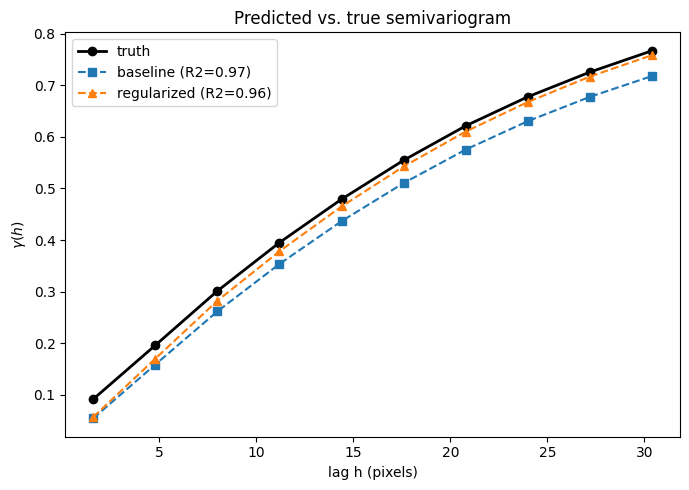

variogram error vs truth  |  baseline 0.0189   regularized 0.0032
lower is better (closer to true spatial structure)


In [ ]:
def mean_variogram(fields, max_lag=32, n_bins=10):
    x = y = np.arange(fields.shape[1])
    gx, gy = np.meshgrid(x, y, indexing="ij")
    coords = (gx.ravel(), gy.ravel())
    edges = np.linspace(0, max_lag, n_bins + 1)
    gams = []
    for f in fields:
        bc, g = gs.vario_estimate(coords, f.ravel(), bin_edges=edges,
                                  sampling_size=4000, sampling_seed=1)
        gams.append(g)
    return bc, np.nanmean(gams, axis=0)

bc, g_true = mean_variogram(true_v)
_,  g_base = mean_variogram(pred_b)
_,  g_reg  = mean_variogram(pred_r)

plt.figure(figsize=(7, 5))
plt.plot(bc, g_true, "ko-", label="truth", lw=2)
plt.plot(bc, g_base, "s--", label=f"baseline (R2={r2_b:.2f})")
plt.plot(bc, g_reg,  "^--", label=f"regularized (R2={r2_r:.2f})")
plt.xlabel("lag h (pixels)"); plt.ylabel(r"$\gamma(h)$")
plt.title("Predicted vs. true semivariogram")
plt.legend(); plt.tight_layout(); plt.show()

# quantify structure match: sum of squared variogram error vs truth
err_base = np.nansum((g_base - g_true)**2)
err_reg  = np.nansum((g_reg  - g_true)**2)
print(f"variogram error vs truth  |  baseline {err_base:.4f}   regularized {err_reg:.4f}")
print("lower is better (closer to true spatial structure)")

### Prediction maps

Eyeball a validation example: coarse input, truth, baseline, regularized.

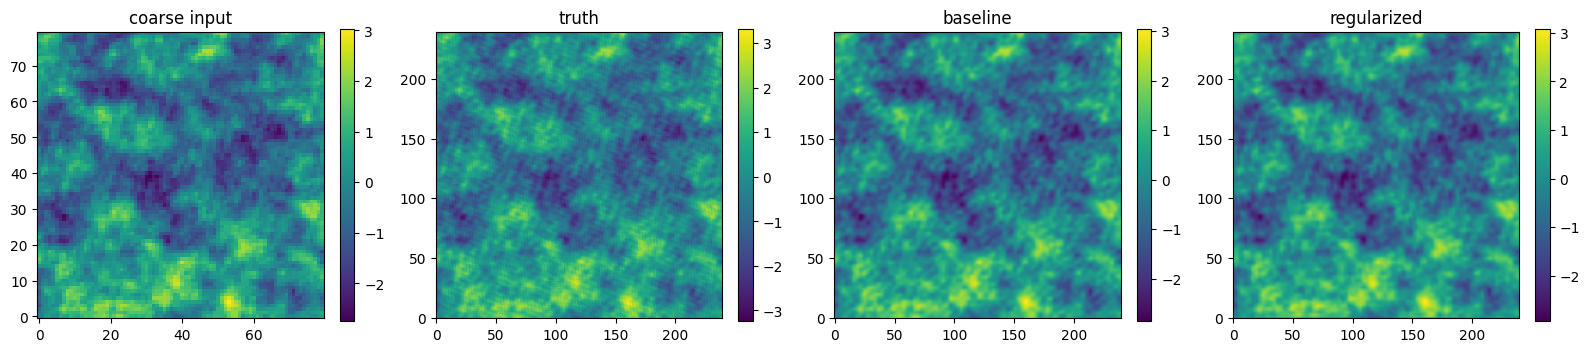

In [ ]:
k = 0
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
inp = Xva.cpu().numpy()[k, -1]     # last coarse step
for a, img, t in zip(
    ax,
    [inp, true_v[k], pred_b[k], pred_r[k]],
    ["coarse input", "truth", "baseline", "regularized"],
):
    im = a.imshow(img, origin="lower", cmap="viridis")
    a.set_title(t); plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## Loss curves

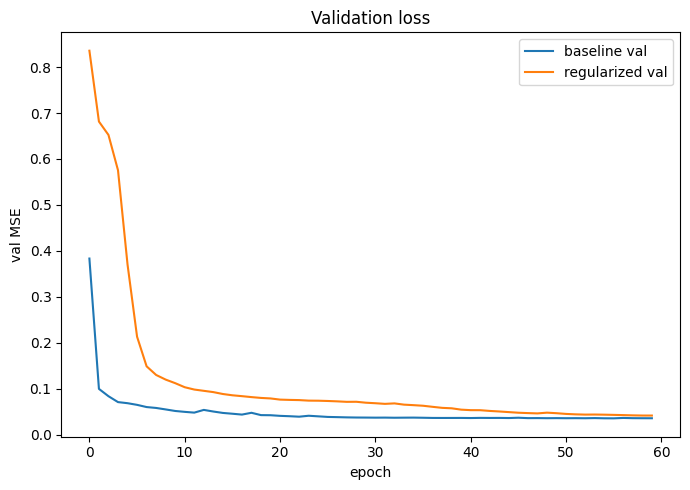

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(hist_base["val"], label="baseline val")
plt.plot(hist_reg["val"], label="regularized val")
plt.xlabel("epoch"); plt.ylabel("val MSE"); plt.legend()
plt.title("Validation loss"); plt.tight_layout(); plt.show()

In [ ]:
# ======================================================================
# Deploy trained models on UNSEEN (out-of-distribution) test sets
# ----------------------------------------------------------------------
# The models were trained on sim_dataset.npz (structure A). Here we run them,
# WITHOUT retraining, on datasets generated from DIFFERENT covariance
# structures, to test spatial generalization.
#
# CRITICAL: we normalize the OOD inputs with the TRAINING mean/std (not the
# OOD set's own stats). A deployed model only knows its training statistics;
# using the test set's stats would be leakage and make the comparison invalid.
# ======================================================================

def evaluate_on_dataset(npz_path, max_lag=None, verbose=True):
    """Load an OOD dataset, run both trained models on ALL of it, and report
    pointwise metrics (MSE/RMSE/MAE/R2) plus variogram error vs truth."""
    d = np.load(npz_path)
    cs = d["coarse_stacks"]          # (N, T, h, w)
    ft = d["fine_targets"]           # (N, H, W)
    true_struct = dict(var=float(d["var"]), len_scale=float(d["len_scale"]),
                       nu=float(d["nu"]))
    Hd = ft.shape[1]
    if max_lag is None:
        max_lag = Hd / 2

    # sanity: OOD grid must match what the model expects
    assert cs.shape[1] == T,  f"stack depth {cs.shape[1]} != trained T={T}"
    assert ft.shape[1] == H,  f"fine size {ft.shape[1]} != trained H={H}"

    # normalize with TRAINING stats (mean, std from the training split)
    Xte = torch.tensor((cs - mean) / std, dtype=torch.float32).to(DEVICE)
    true = ft                                   # keep truth in ORIGINAL units

    def run(model):
        model.eval()
        with torch.no_grad():
            pred_norm = model(Xte).cpu().numpy()[:, 0]   # normalized units
        pred = pred_norm * std + mean                    # back to ORIGINAL units
        mse_v  = np.mean((pred - true)**2)
        return pred, mse_v, np.sqrt(mse_v), np.mean(np.abs(pred - true)), float(r2_score(pred, true))

    pred_b, mse_b, rmse_b, mae_b, r2_b = run(model_base)
    pred_r, mse_r, rmse_r, mae_r, r2_r = run(model_reg)

    # variogram error vs truth (structure match), in original units
    bc, g_true = mean_variogram(true,   max_lag=max_lag)
    _,  g_base = mean_variogram(pred_b, max_lag=max_lag)
    _,  g_reg  = mean_variogram(pred_r, max_lag=max_lag)
    verr_b = np.nansum((g_base - g_true)**2)
    verr_r = np.nansum((g_reg  - g_true)**2)

    if verbose:
        print(f"\n=== {npz_path} ===")
        print(f"  test structure: nu={true_struct['nu']}, "
              f"len_scale={true_struct['len_scale']}, var={true_struct['var']}")
        print(f"  {'model':11s} {'MSE':>8} {'RMSE':>8} {'MAE':>8} {'R2':>8} {'varErr':>9}")
        print(f"  {'baseline':11s} {mse_b:8.4f} {rmse_b:8.4f} {mae_b:8.4f} {r2_b:8.4f} {verr_b:9.4f}")
        print(f"  {'regularized':11s} {mse_r:8.4f} {rmse_r:8.4f} {mae_r:8.4f} {r2_r:8.4f} {verr_r:9.4f}")

    return dict(path=npz_path, struct=true_struct,
                baseline=dict(mse=mse_b, rmse=rmse_b, mae=mae_b, r2=r2_b, verr=verr_b),
                regularized=dict(mse=mse_r, rmse=rmse_r, mae=mae_r, r2=r2_r, verr=verr_r))

In [ ]:
# --- run on each OOD test set you generated ---
ood_files = [
    "ood_nu1.0_ls12.npz",
    "ood_nu1.5_ls10.npz",
    "ood_nu2.0_ls25.npz",
]

results = []
for f in ood_files:
    try:
        results.append(evaluate_on_dataset(f))
    except FileNotFoundError:
        print(f"skipping {f} (not found — generate it first)")


=== ood_nu1.0_ls12.npz ===
  test structure: nu=1.0, len_scale=12.0, var=2.0
  model            MSE     RMSE      MAE       R2    varErr
  baseline      0.0132   0.1150   0.0861   0.9933    0.0136
  regularized   0.0214   0.1462   0.1076   0.9892    0.0249

=== ood_nu1.5_ls10.npz ===
  test structure: nu=1.5, len_scale=10.0, var=2.0
  model            MSE     RMSE      MAE       R2    varErr
  baseline      0.0051   0.0716   0.0540   0.9974    0.0077
  regularized   0.0127   0.1125   0.0800   0.9936    0.0369

=== ood_nu2.0_ls25.npz ===
  test structure: nu=2.0, len_scale=25.0, var=2.0
  model            MSE     RMSE      MAE       R2    varErr
  baseline      0.0019   0.0437   0.0383   0.9991    0.0000
  regularized   0.0058   0.0760   0.0459   0.9971    0.0125


In [ ]:
def plot_variograms_for_dataset(npz_path):
    d = np.load(npz_path)
    cs, ft = d["coarse_stacks"], d["fine_targets"]
    struct = f"nu={float(d['nu'])}, len_scale={float(d['len_scale'])}, var={float(d['var'])}"
    Hd = ft.shape[1]
    max_lag = Hd / 2

    Xte = torch.tensor((cs - mean) / std, dtype=torch.float32).to(DEVICE)

    def predict(model):
        model.eval()
        with torch.no_grad():
            p = model(Xte).cpu().numpy()[:, 0]
        return p * std + mean          # back to original units

    pred_b = predict(model_base)
    pred_r = predict(model_reg)

    bc, g_true = mean_variogram(ft,     max_lag=max_lag)
    _,  g_base = mean_variogram(pred_b, max_lag=max_lag)
    _,  g_reg  = mean_variogram(pred_r, max_lag=max_lag)

    err_b = np.nansum((g_base - g_true)**2)
    err_r = np.nansum((g_reg  - g_true)**2)

    plt.figure(figsize=(7, 5))
    plt.plot(bc, g_true, "ko-", label="truth", lw=2)
    plt.plot(bc, g_base, "s--", label=f"baseline (varErr={err_b:.4f})")
    plt.plot(bc, g_reg,  "^--", label=f"regularized (varErr={err_r:.4f})")
    plt.axvline(float(d["len_scale"]), color="grey", ls=":", lw=1, label="true range")
    plt.xlabel("lag h (pixels)"); plt.ylabel(r"$\gamma(h)$")
    plt.title(f"Predicted vs. true semivariogram\n{npz_path}  ({struct})")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()


for f in ood_files:
    try:
        plot_variograms_for_dataset(f)
    except FileNotFoundError:
        print(f"skipping {f} (not found)")